# 📊 Raw Data — Exploratory Data Analysis

This notebook performs a **comprehensive EDA on the raw exchange-rate data** 
(`data/processed/exchange_rates_raw_long.csv`) **before** any cleaning or 
feature engineering is applied by `clean_transform.py`.

### Sections
1. Imports & Data Loading
2. Schema & Basic Info
3. Null / Missing Value Analysis
4. Duplicate Detection
5. Descriptive Statistics
6. Target-Currency Breakdown
7. Date Coverage & Gaps
8. Rate Distribution (Overall)
9. Rate Distribution by Major Currency
10. Log-Scale Distribution
11. Time-Series Trends (Major Currencies)
12. Correlation Heatmap — Raw Rates
13. Correlation Heatmap — Daily Returns
14. Feature Engineering (new cleaned df)
15. Correlation — Engineered Features
16. Pairwise Scatter: Engineered vs Raw
17. Volatility vs Mean Return
18. Summary & Key Takeaways

---
## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

RAW_PATH = "../data/processed/exchange_rates_raw_long.csv"

df_raw = pd.read_csv(RAW_PATH, parse_dates=["date"])
print(f"Loaded {len(df_raw):,} rows from {RAW_PATH}")
df_raw.head()

Loaded 51,615 rows from ../data/processed/exchange_rates_raw_long.csv


,date,base_currency,target_currency,rate
0,2025-07-12,USD,AED,3.6725
1,2025-07-13,USD,AED,3.6725
2,2025-07-14,USD,AED,3.6725
3,2025-07-15,USD,AED,3.6725
4,2025-07-16,USD,AED,3.6725


---
## 2. Schema & Basic Info

In [2]:
print("Shape:", df_raw.shape)
print("\nColumn dtypes:")
print(df_raw.dtypes)
print("\nMemory usage:")
print(df_raw.memory_usage(deep=True))
print(f"\nTotal memory: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Shape: (51615, 4)

Column dtypes:
date               datetime64[ns]
base_currency              object
target_currency            object
rate                      float64
dtype: object

Memory usage:
Index                  132
date                412920
base_currency      2683980
target_currency    2683980
rate                412920
dtype: int64

Total memory: 5.91 MB


---
## 3. Null / Missing Value Analysis

Null value summary per column:
                 null_count  null_pct
date                      0       0.0
base_currency             0       0.0
target_currency           0       0.0
rate                      0       0.0


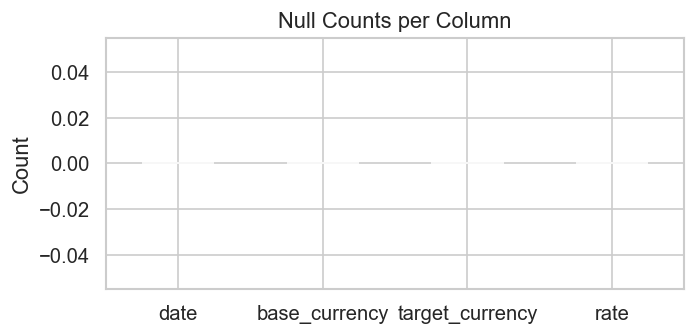

  ✔ Column 'base_currency' — no hidden empty strings
  ✔ Column 'target_currency' — no hidden empty strings


In [3]:
null_counts = df_raw.isnull().sum()
null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)

null_summary = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct})
print("Null value summary per column:")
print(null_summary)

# Visualise
fig, ax = plt.subplots(figsize=(6, 3))
null_summary["null_count"].plot.bar(ax=ax, color="#e74c3c", edgecolor="white")
ax.set_title("Null Counts per Column")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Check for hidden missing values (empty strings, whitespace)
for col in df_raw.select_dtypes(include="object").columns:
    empty_str = (df_raw[col].str.strip() == "").sum()
    if empty_str:
        print(f"  ⚠ Column '{col}' has {empty_str} empty-string values")
    else:
        print(f"  ✔ Column '{col}' — no hidden empty strings")

---
## 4. Duplicate Detection

In [4]:
# Exact row duplicates
exact_dupes = df_raw.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes}")

# Logical duplicates: same (date, base_currency, target_currency) with different rates
key_cols = ["date", "base_currency", "target_currency"]
key_dupes = df_raw.duplicated(subset=key_cols, keep=False)
n_key_dupes = key_dupes.sum()
print(f"Rows with duplicate (date, base, target) keys: {n_key_dupes}")

if n_key_dupes > 0:
    print("\nSample conflicting rows:")
    display(df_raw[key_dupes].sort_values(key_cols).head(10))

Exact duplicate rows: 0
Rows with duplicate (date, base, target) keys: 0


---
## 5. Descriptive Statistics

In [5]:
print("Overall rate statistics:")
print(df_raw["rate"].describe())

print(f"\nSkewness  : {df_raw['rate'].skew():.4f}")
print(f"Kurtosis  : {df_raw['rate'].kurtosis():.4f}")

# IQR-based outlier count
Q1, Q3 = df_raw["rate"].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = ((df_raw["rate"] < Q1 - 1.5 * IQR) | (df_raw["rate"] > Q3 + 1.5 * IQR)).sum()
print(f"\nIQR-based outlier rows: {outliers} ({outliers/len(df_raw)*100:.1f}%)")

Overall rate statistics:
count    5.161500e+04
mean     6.083946e+03
std      7.672290e+04
min      1.900000e-04
25%      2.855250e+00
50%      2.114000e+01
75%      1.768650e+02
max      1.391109e+06
Name: rate, dtype: float64

Skewness  : 16.6360
Kurtosis  : 278.8583

IQR-based outlier rows: 10125 (19.6%)


---
## 6. Target-Currency Breakdown

In [6]:
currency_stats = (
    df_raw.groupby("target_currency")["rate"]
    .agg(["count", "mean", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)
print(f"Total unique target currencies: {df_raw['target_currency'].nunique()}")
print(f"Unique base currencies: {df_raw['base_currency'].unique()}")
print(f"\nRows per currency — min: {currency_stats['count'].min()}, max: {currency_stats['count'].max()}")

# Show top-10 highest-rate and bottom-10 lowest-rate currencies
print("\n--- Top 10 by mean rate ---")
display(currency_stats.head(10))
print("\n--- Bottom 10 by mean rate ---")
display(currency_stats.tail(10))

Total unique target currencies: 166
Unique base currencies: ['USD']

Rows per currency — min: 173, max: 366

--- Top 10 by mean rate ---


,count,mean,std,min,max
target_currency,,,,,
IRR,366,663001.338798,624022.742770,41913.00,1391109.0
LBP,261,89582.153257,847.811041,87090.00,92976.0
VND,366,26197.352459,100.764007,25845.00,26360.0
LAK,260,21547.457692,321.667677,21047.00,22595.0
IDR,366,16909.202186,496.411150,16143.00,18114.0
UZS,366,12162.893443,201.558169,11888.00,12741.0
GNF,255,8420.090196,294.158381,7957.00,8803.0
PYG,257,6733.081712,439.820068,6042.00,7671.0
SYP,259,5885.491699,5968.763509,113.26,13069.0



--- Bottom 10 by mean rate ---


,count,mean,std,min,max
target_currency,,,,,
SHP,255,0.745503,0.007598,0.72457,0.76576
XDR,366,0.731545,0.003214,0.72281,0.73792
JOD,317,0.709000,0.000000,0.70900,0.70900
OMR,366,0.384500,0.000000,0.38450,0.38450
BHD,366,0.376000,0.000000,0.37600,0.37600
KWD,366,0.306486,0.000867,0.30484,0.30871
XAG,364,0.017253,0.005234,0.00872,0.02724
XPD,261,0.000708,0.000107,0.00049,0.00091
XPT,261,0.000574,0.000106,0.00036,0.00076


---
## 7. Date Coverage & Gap Analysis

In [7]:
date_min, date_max = df_raw["date"].min(), df_raw["date"].max()
print(f"Date range: {date_min.date()} → {date_max.date()}")
print(f"Calendar span: {(date_max - date_min).days} days")

unique_dates = df_raw["date"].nunique()
full_range = pd.date_range(date_min, date_max, freq="D")
missing_dates = set(full_range) - set(df_raw["date"].unique())

print(f"Unique dates in data: {unique_dates}")
print(f"Expected calendar days: {len(full_range)}")
print(f"Missing calendar dates: {len(missing_dates)}")

if missing_dates:
    missing_sorted = sorted(missing_dates)
    missing_dow = pd.Series([d.day_name() for d in missing_sorted])
    print(f"\nDay-of-week breakdown of missing dates:")
    print(missing_dow.value_counts())
    print(f"\nFirst 15 missing dates:")
    for d in missing_sorted[:15]:
        print(f"  {d.date()} ({d.day_name()})")

# Rows-per-date distribution
rows_per_date = df_raw.groupby("date").size()
print(f"\nRows per date — min: {rows_per_date.min()}, max: {rows_per_date.max()}, mean: {rows_per_date.mean():.1f}")

Date range: 2025-07-11 → 2026-07-12
Calendar span: 366 days
Unique dates in data: 367
Expected calendar days: 367
Missing calendar dates: 0

Rows per date — min: 70, max: 166, mean: 140.6


---
## 8. Rate Distribution — Overall

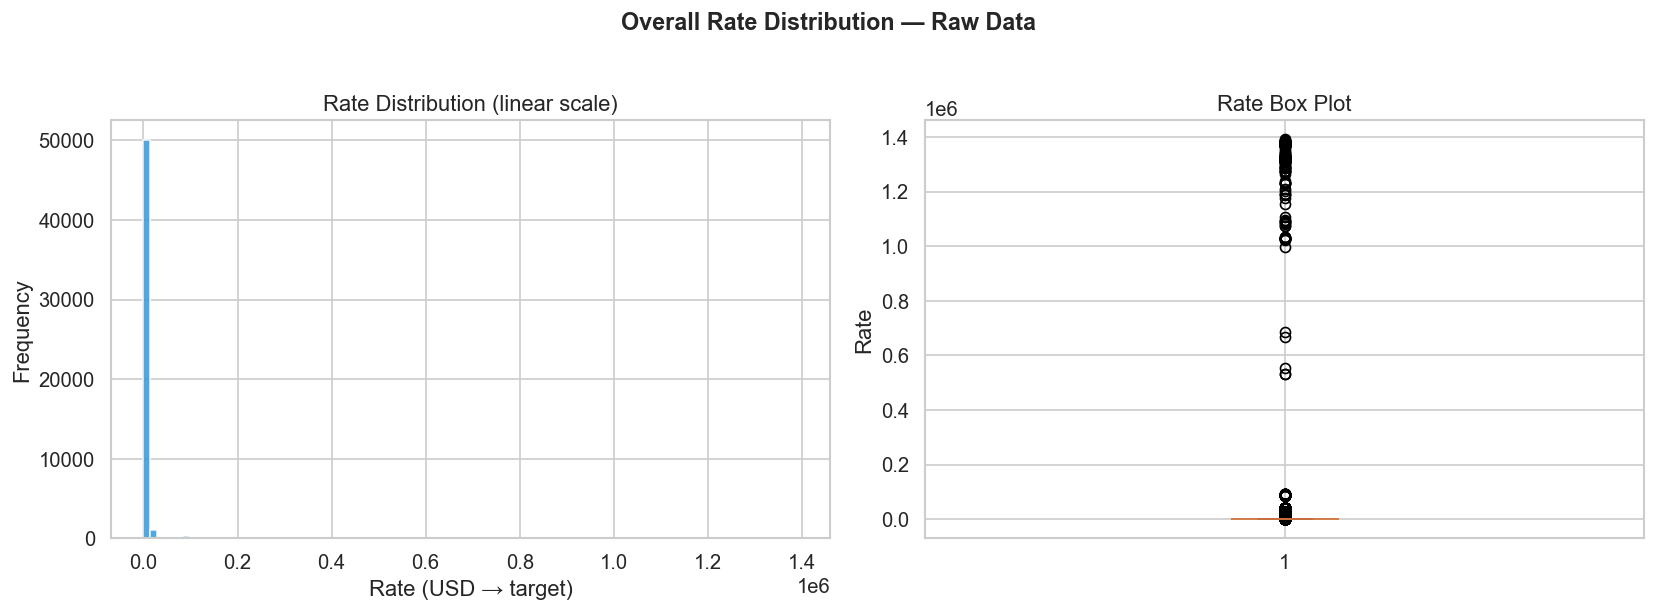

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_raw["rate"], bins=100, color="#3498db", edgecolor="white", alpha=0.85)
axes[0].set_title("Rate Distribution (linear scale)")
axes[0].set_xlabel("Rate (USD → target)")
axes[0].set_ylabel("Frequency")

# Box plot (clipped for readability)
axes[1].boxplot(df_raw["rate"].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor="#2ecc71", alpha=0.7))
axes[1].set_title("Rate Box Plot")
axes[1].set_ylabel("Rate")

fig.suptitle("Overall Rate Distribution — Raw Data", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Rate Distribution by Major Currencies

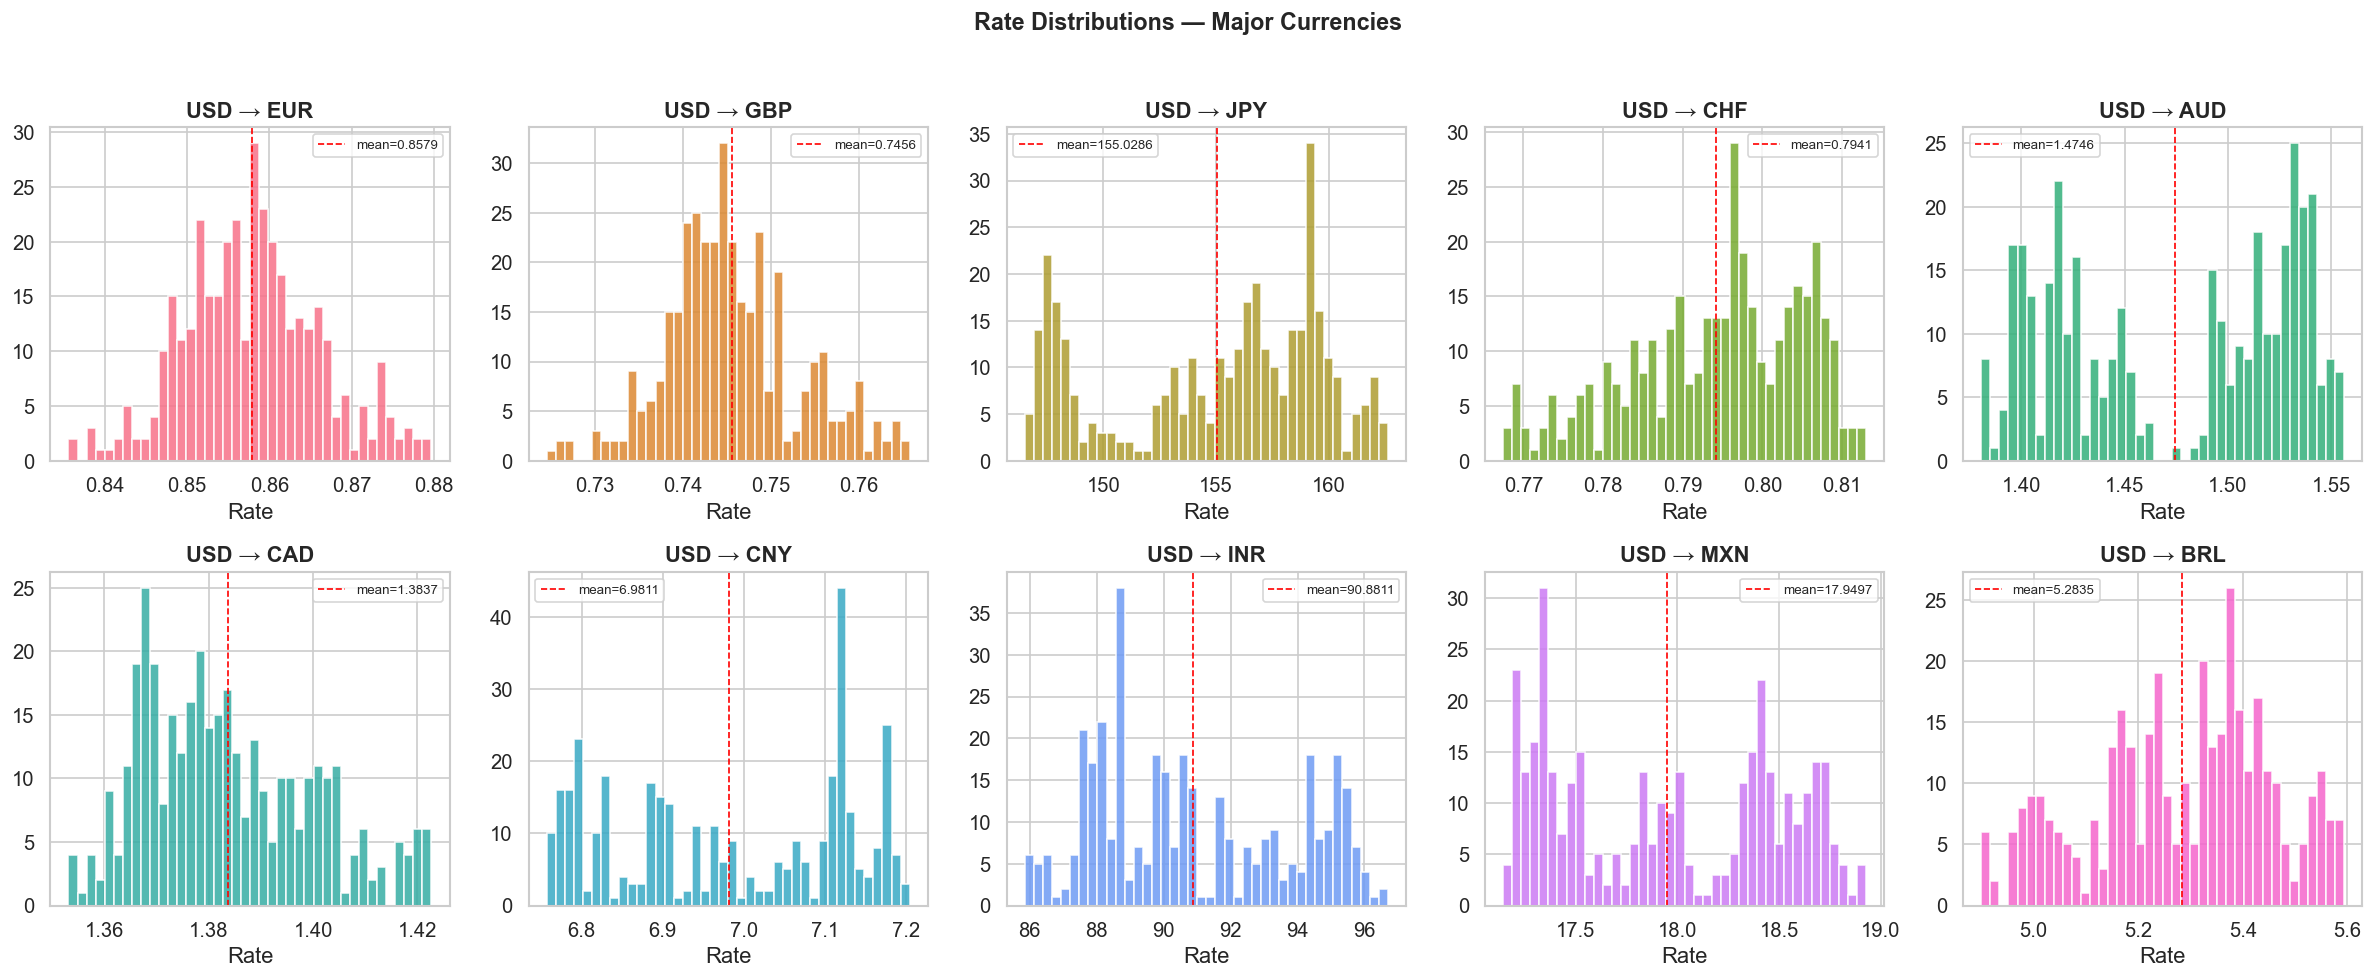

In [9]:
MAJOR = ["EUR", "GBP", "JPY", "CHF", "AUD", "CAD", "CNY", "INR", "MXN", "BRL"]
MAJOR = [c for c in MAJOR if c in df_raw["target_currency"].unique()]

df_major = df_raw[df_raw["target_currency"].isin(MAJOR)].copy()

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=False)
axes = axes.flatten()

for i, cur in enumerate(MAJOR):
    sub = df_major[df_major["target_currency"] == cur]["rate"]
    axes[i].hist(sub, bins=40, color=sns.color_palette("husl", len(MAJOR))[i],
                 edgecolor="white", alpha=0.85)
    axes[i].set_title(f"USD → {cur}", fontweight="bold")
    axes[i].set_xlabel("Rate")
    axes[i].axvline(sub.mean(), color="red", ls="--", lw=1, label=f"mean={sub.mean():.4f}")
    axes[i].legend(fontsize=8)

for j in range(len(MAJOR), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Rate Distributions — Major Currencies", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 10. Log-Scale Distribution

Because rates span several orders of magnitude (0.0002 to 1.4 M), a log transform reveals the true shape.

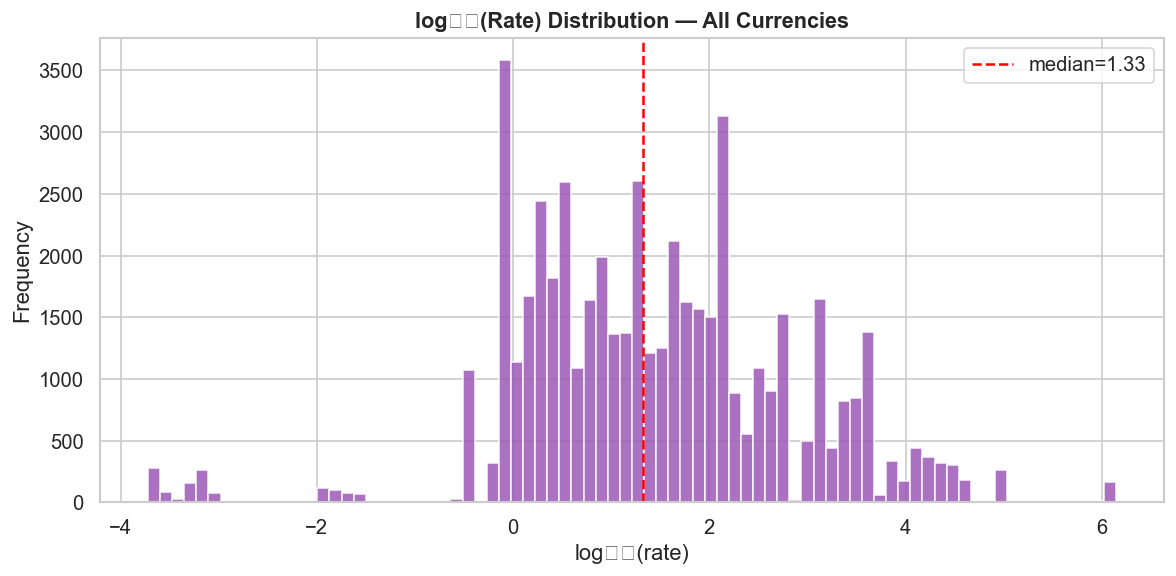

In [10]:
log_rates = np.log10(df_raw["rate"].replace(0, np.nan).dropna())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(log_rates, bins=80, color="#9b59b6", edgecolor="white", alpha=0.85)
ax.set_title("log₁₀(Rate) Distribution — All Currencies", fontsize=13, fontweight="bold")
ax.set_xlabel("log₁₀(rate)")
ax.set_ylabel("Frequency")
ax.axvline(log_rates.median(), color="red", ls="--", label=f"median={log_rates.median():.2f}")
ax.legend()
plt.tight_layout()
plt.show()

---
## 11. Time-Series Trends — Major Currencies

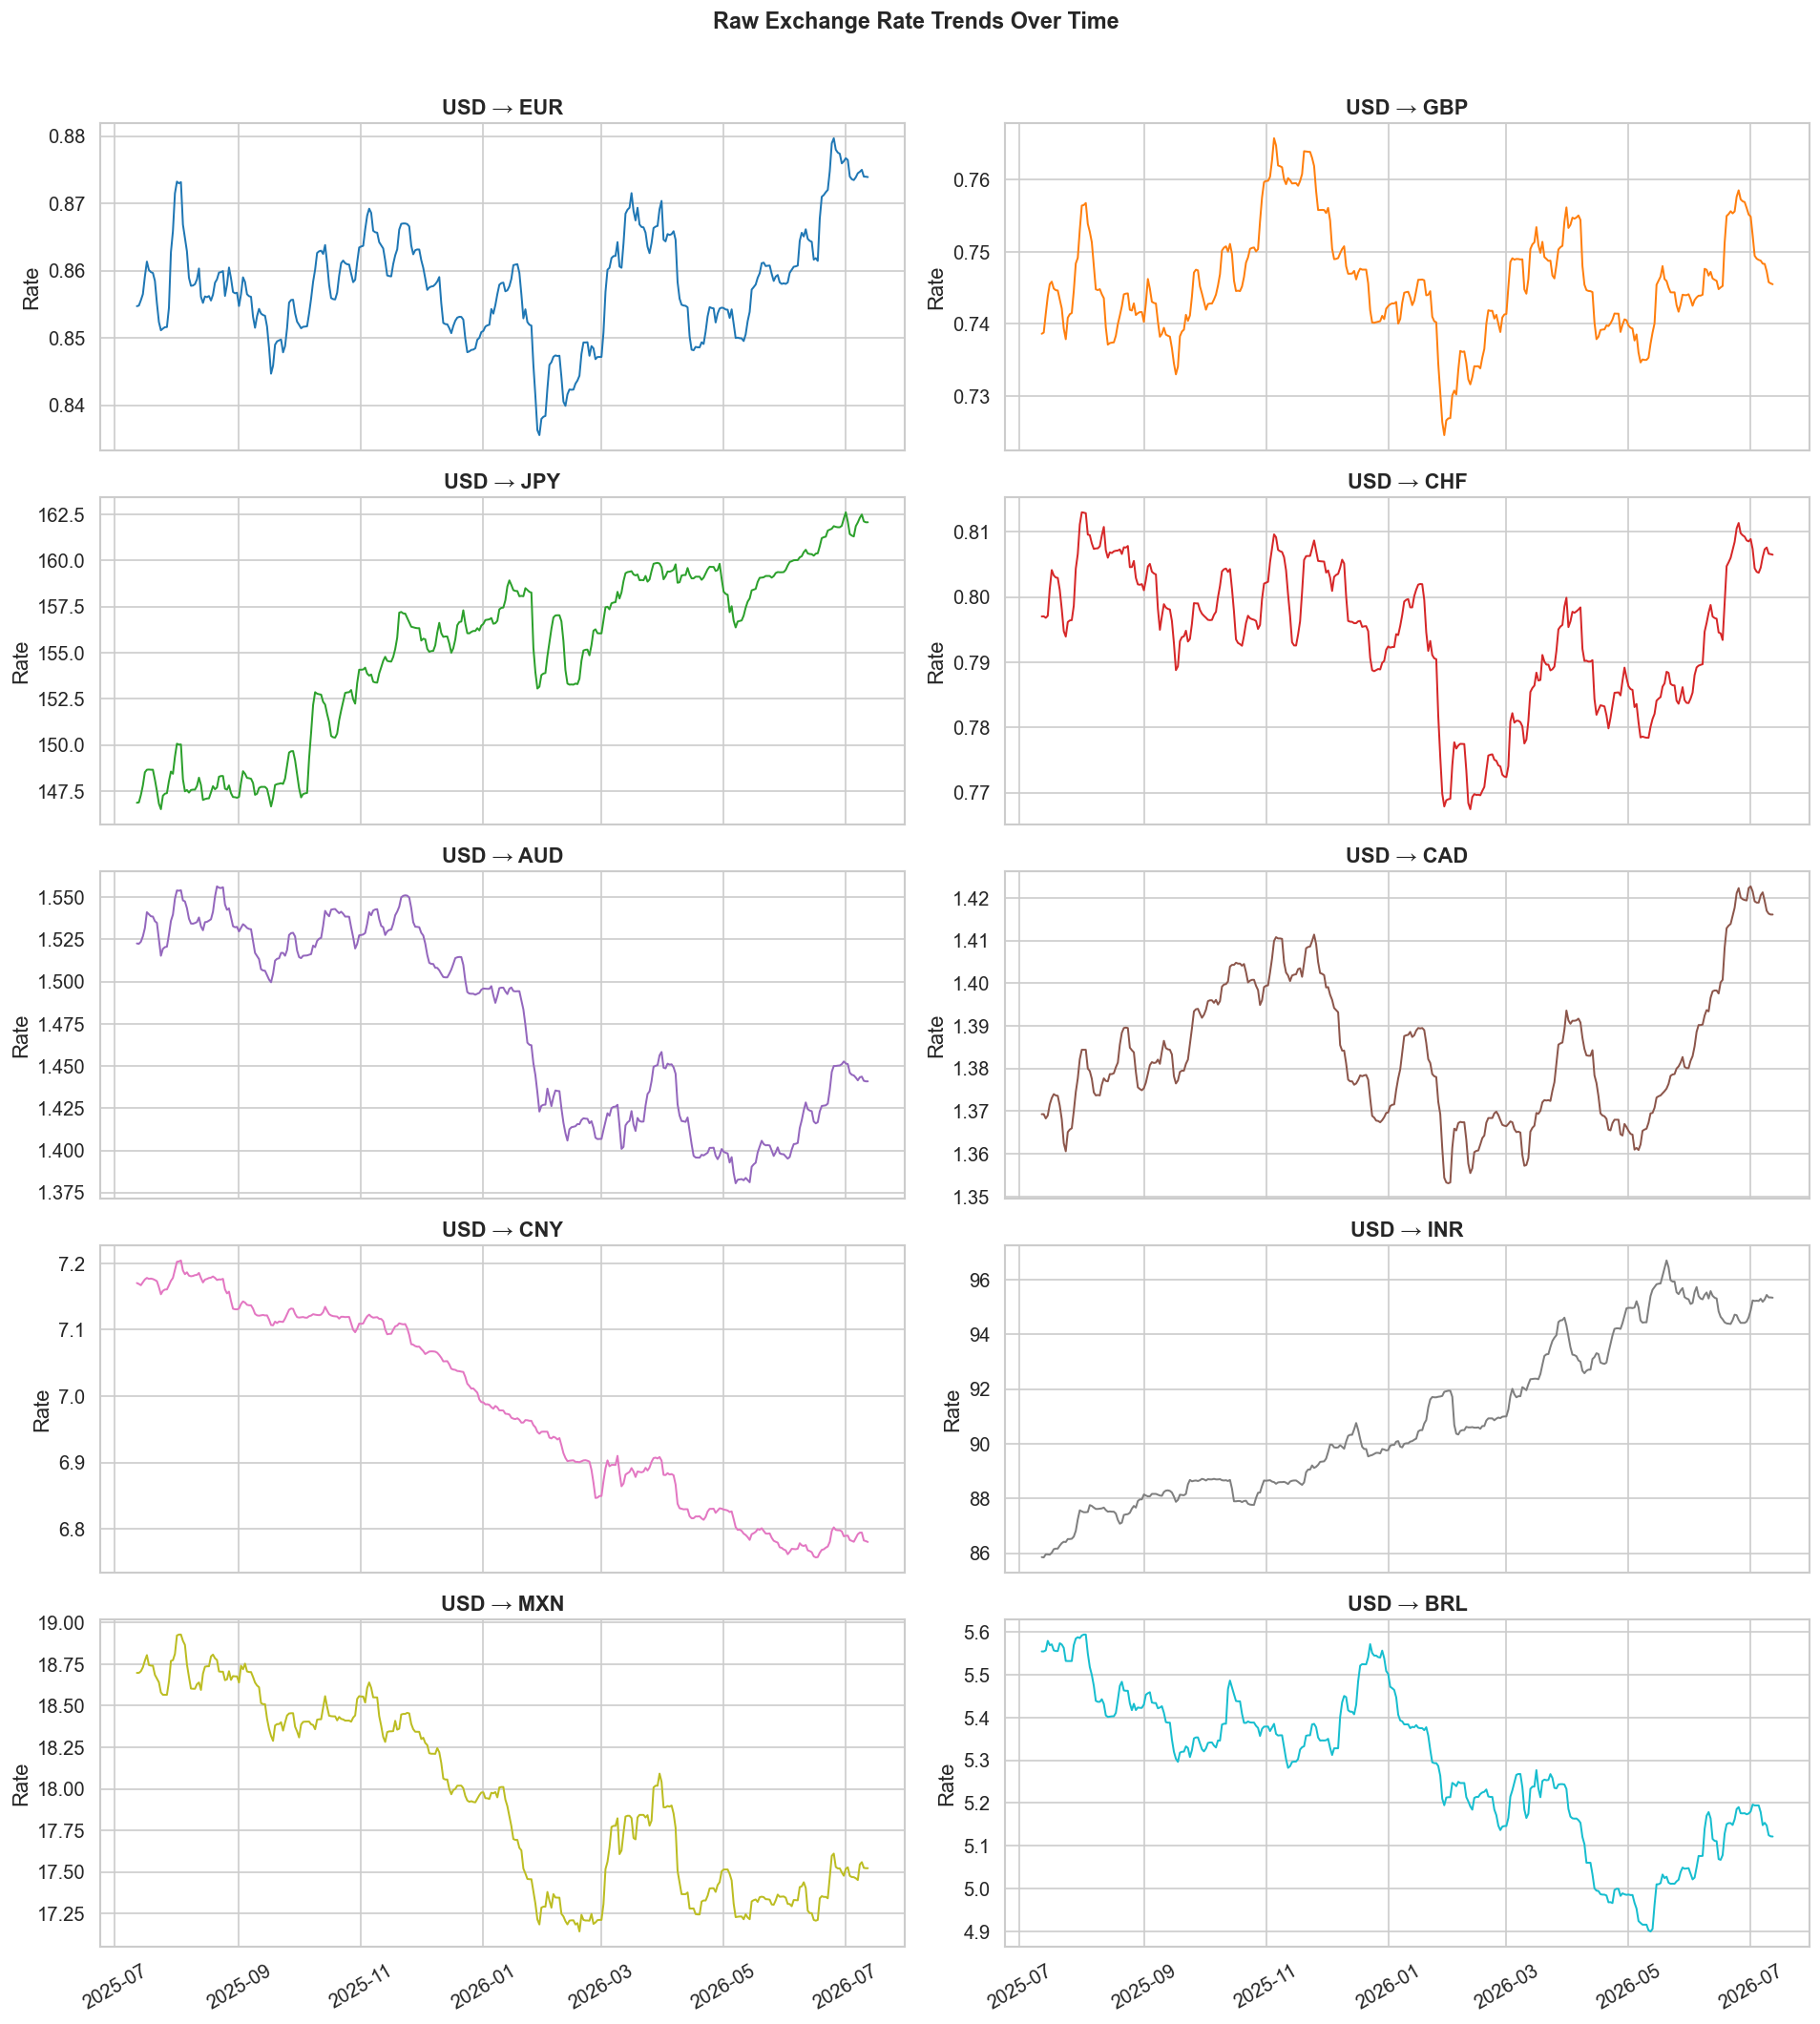

In [11]:
ncols = 2
nrows = -(-len(MAJOR) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5), sharex=True)
axes = axes.flatten()

for i, cur in enumerate(MAJOR):
    sub = df_major[df_major["target_currency"] == cur].sort_values("date")
    axes[i].plot(sub["date"], sub["rate"], linewidth=1.2, color=sns.color_palette("tab10")[i % 10])
    axes[i].set_title(f"USD → {cur}", fontweight="bold")
    axes[i].set_ylabel("Rate")
    axes[i].tick_params(axis="x", rotation=30)

for j in range(len(MAJOR), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Raw Exchange Rate Trends Over Time", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 12. Correlation Heatmap — Raw Rates

Pivot the raw rates into a wide table (date × currency) and compute Pearson correlation.

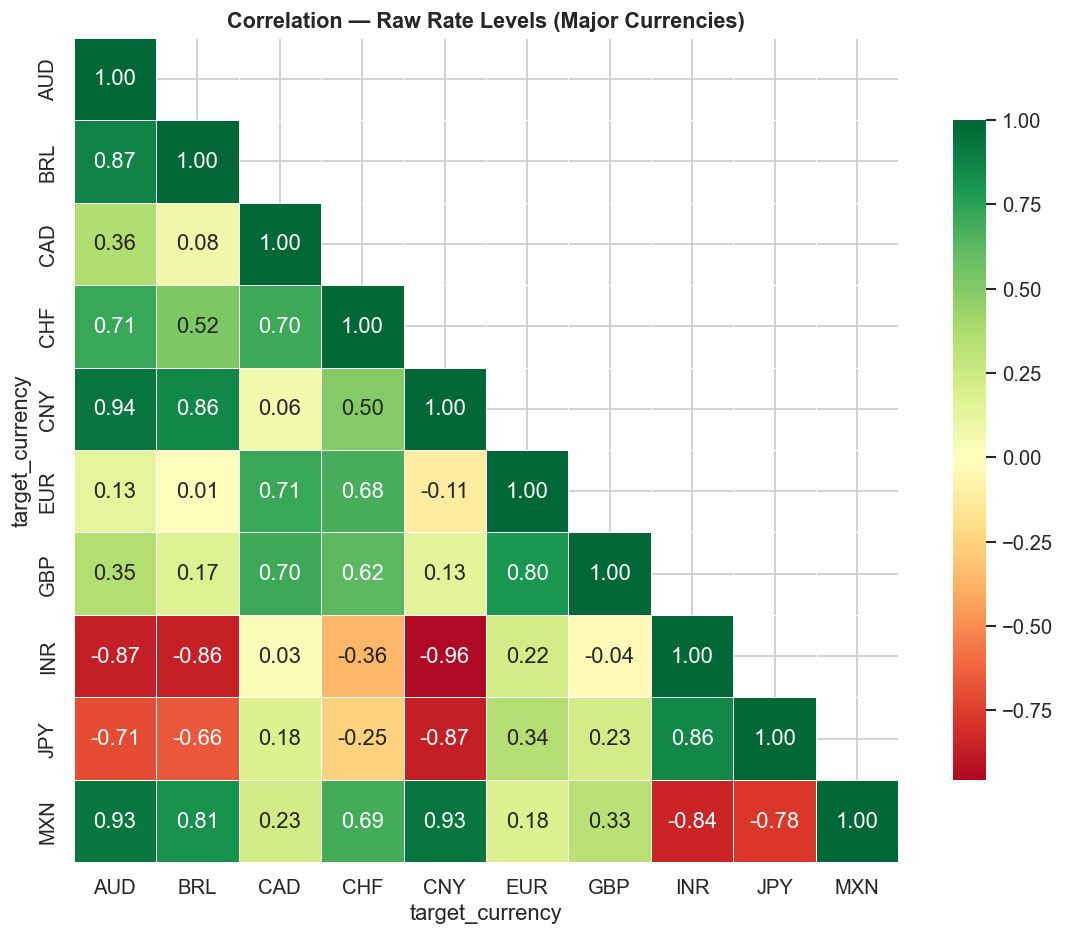

⚠ Note: Correlating raw rate *levels* can be misleading (spurious correlation).
  The next cell uses daily *returns* for a more meaningful comparison.


In [12]:
pivot_rates = df_major.pivot_table(index="date", columns="target_currency", values="rate")
corr_rates = pivot_rates.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_rates, dtype=bool), k=1)
sns.heatmap(corr_rates, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation — Raw Rate Levels (Major Currencies)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("⚠ Note: Correlating raw rate *levels* can be misleading (spurious correlation).")
print("  The next cell uses daily *returns* for a more meaningful comparison.")

---
## 13. Correlation Heatmap — Daily Returns (pct_change)

Daily percentage change removes the level effect and reveals co-movement.

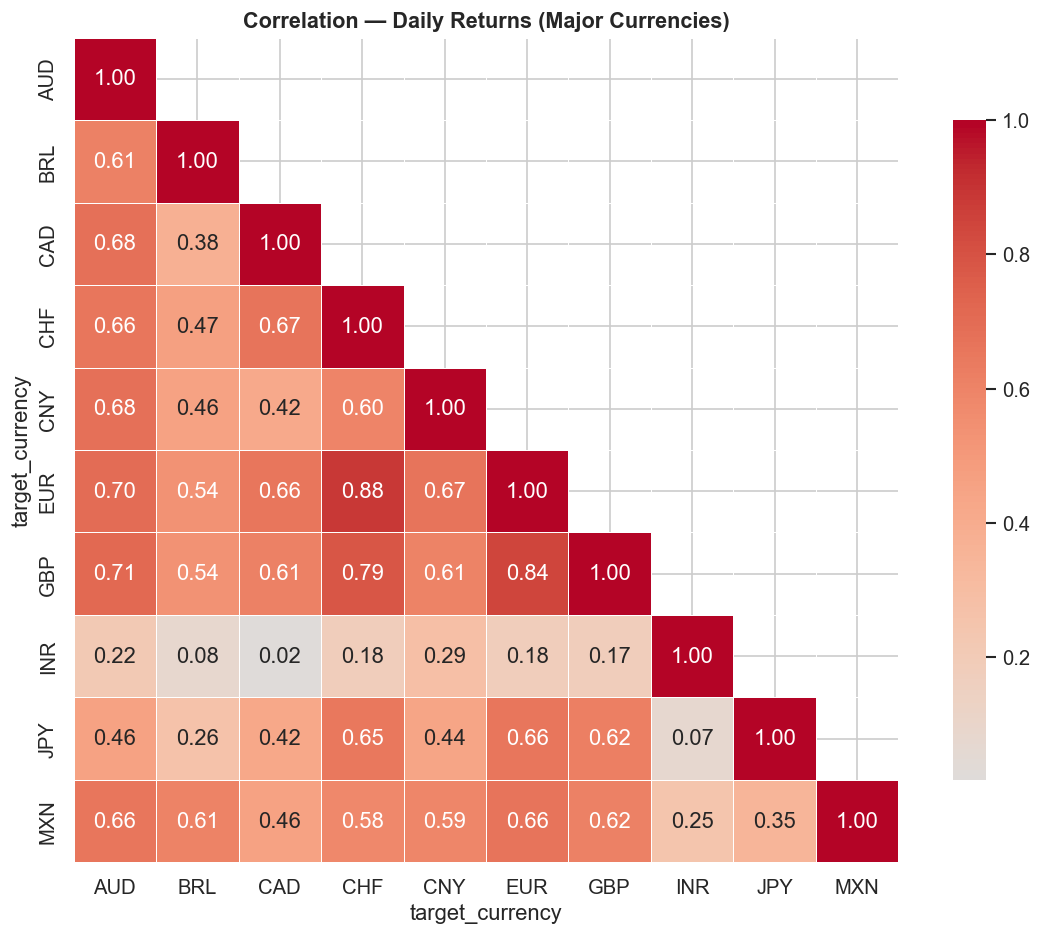

In [13]:
returns = pivot_rates.pct_change().dropna(how="all")
corr_returns = returns.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_returns, dtype=bool), k=1)
sns.heatmap(corr_returns, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation — Daily Returns (Major Currencies)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 14. Feature Engineering (new cleaned DataFrame)

We create a **separate** `df_feat` to explore derived features without modifying the raw data.  
**Nothing is saved to the database.**

New features:
- `daily_pct_change` — day-over-day return
- `ma_7`, `ma_30` — 7- and 30-day rolling means
- `volatility_30d` — 30-day rolling std of daily returns
- `rate_to_ma7_ratio` — rate / MA-7 (mean-reversion signal)
- `momentum_14d` — cumulative return over 14 days
- `log_rate` — log-transformed rate

In [14]:
df_feat = df_major.copy().sort_values(["target_currency", "date"]).reset_index(drop=True)

g = df_feat.groupby("target_currency")["rate"]

# Core derived features
df_feat["daily_pct_change"] = g.pct_change()
df_feat["ma_7"]  = g.transform(lambda s: s.rolling(7,  min_periods=1).mean())
df_feat["ma_30"] = g.transform(lambda s: s.rolling(30, min_periods=1).mean())
df_feat["volatility_30d"] = (
    df_feat.groupby("target_currency")["daily_pct_change"]
    .transform(lambda s: s.rolling(30, min_periods=2).std())
)

# New experimental features
df_feat["rate_to_ma7_ratio"] = df_feat["rate"] / df_feat["ma_7"]
df_feat["momentum_14d"] = g.transform(lambda s: s.pct_change(periods=14))
df_feat["log_rate"] = np.log(df_feat["rate"])

print(f"df_feat shape: {df_feat.shape}")
print(f"\nNew columns: {[c for c in df_feat.columns if c not in df_raw.columns]}")
df_feat.head(10)

df_feat shape: (3660, 11)

New columns: ['daily_pct_change', 'ma_7', 'ma_30', 'volatility_30d', 'rate_to_ma7_ratio', 'momentum_14d', 'log_rate']


,date,base_currency,target_currency,rate,daily_pct_change,ma_7,ma_30,volatility_30d,rate_to_ma7_ratio,momentum_14d,log_rate
0,2025-07-12,USD,AUD,1.5226,NaN,1.522600,1.522600,NaN,1.000000,NaN,0.420419
1,2025-07-13,USD,AUD,1.5224,-0.000131,1.522500,1.522500,NaN,0.999934,NaN,0.420288
2,2025-07-14,USD,AUD,1.5236,0.000788,1.522867,1.522867,0.000650,1.000482,NaN,0.421076
3,2025-07-15,USD,AUD,1.5268,0.002100,1.523850,1.523850,0.001122,1.001936,NaN,0.423174
4,2025-07-16,USD,AUD,1.5317,0.003209,1.525420,1.525420,0.001466,1.004117,NaN,0.426378
5,2025-07-17,USD,AUD,1.5411,0.006137,1.528033,1.528033,0.002435,1.008551,NaN,0.432496
6,2025-07-18,USD,AUD,1.5399,-0.000779,1.529729,1.529729,0.002539,1.006649,NaN,0.431717
7,2025-07-19,USD,AUD,1.5387,-0.000779,1.532029,1.530850,0.002528,1.004355,NaN,0.430938
8,2025-07-20,USD,AUD,1.5385,-0.000130,1.534329,1.531700,0.002411,1.002719,NaN,0.430808
9,2025-07-21,USD,AUD,1.5358,-0.001755,1.536071,1.532110,0.002475,0.999823,NaN,0.429051


---
## 15. Correlation — Engineered Features

How do the new features correlate with each other and with the raw rate?

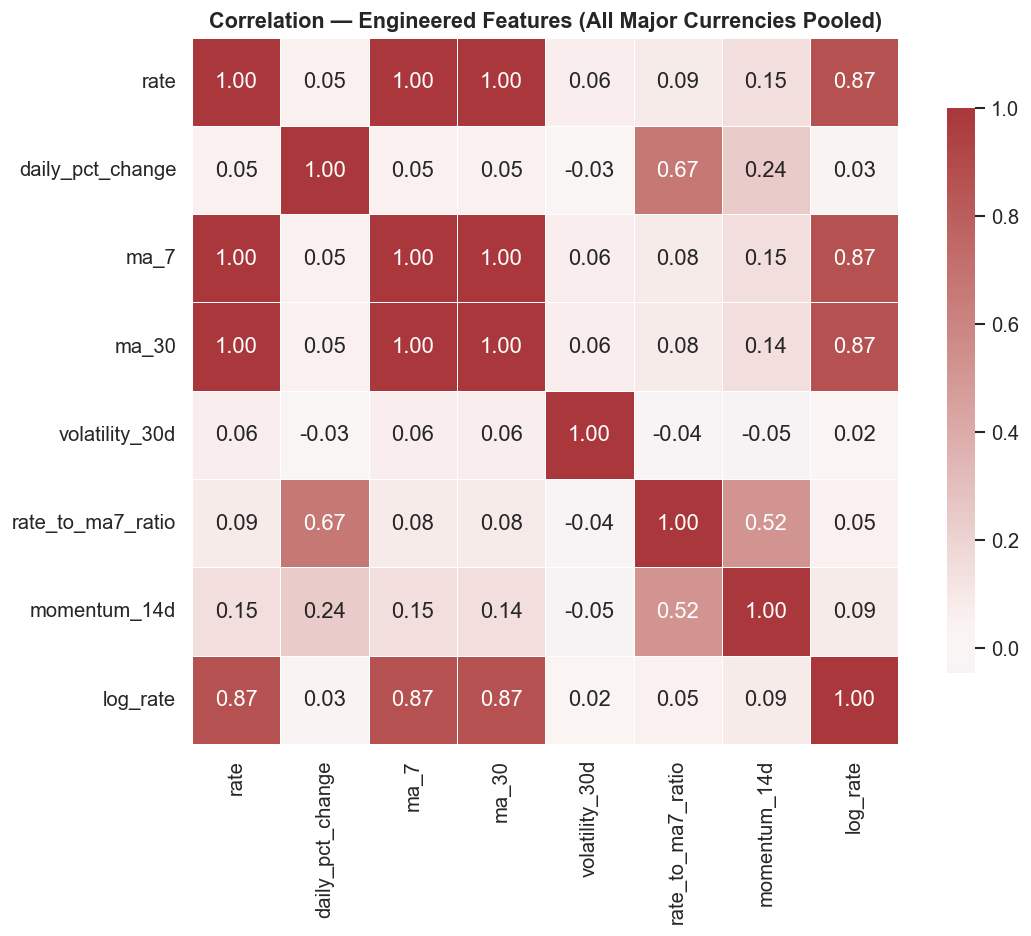


Key observations:
  rate ↔ log_rate           : 0.871
  rate ↔ ma_7               : 1.000
  rate ↔ volatility_30d     : 0.064
  daily_pct_change ↔ momentum_14d : 0.239
  rate_to_ma7_ratio ↔ momentum_14d: 0.520


In [15]:
feature_cols = ["rate", "daily_pct_change", "ma_7", "ma_30",
                "volatility_30d", "rate_to_ma7_ratio", "momentum_14d", "log_rate"]

corr_feat = df_feat[feature_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_feat, annot=True, fmt=".2f", cmap="vlag",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation — Engineered Features (All Major Currencies Pooled)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Comparison: which feature pairs changed most vs raw-only correlation?
raw_only_cols = ["rate"]
print("\nKey observations:")
print(f"  rate ↔ log_rate           : {corr_feat.loc['rate','log_rate']:.3f}")
print(f"  rate ↔ ma_7               : {corr_feat.loc['rate','ma_7']:.3f}")
print(f"  rate ↔ volatility_30d     : {corr_feat.loc['rate','volatility_30d']:.3f}")
print(f"  daily_pct_change ↔ momentum_14d : {corr_feat.loc['daily_pct_change','momentum_14d']:.3f}")
print(f"  rate_to_ma7_ratio ↔ momentum_14d: {corr_feat.loc['rate_to_ma7_ratio','momentum_14d']:.3f}")

---
## 15b. Per-Currency Feature Correlation

The pooled heatmap above mixes all currency scales. Let's see how correlations differ **within** individual currencies.

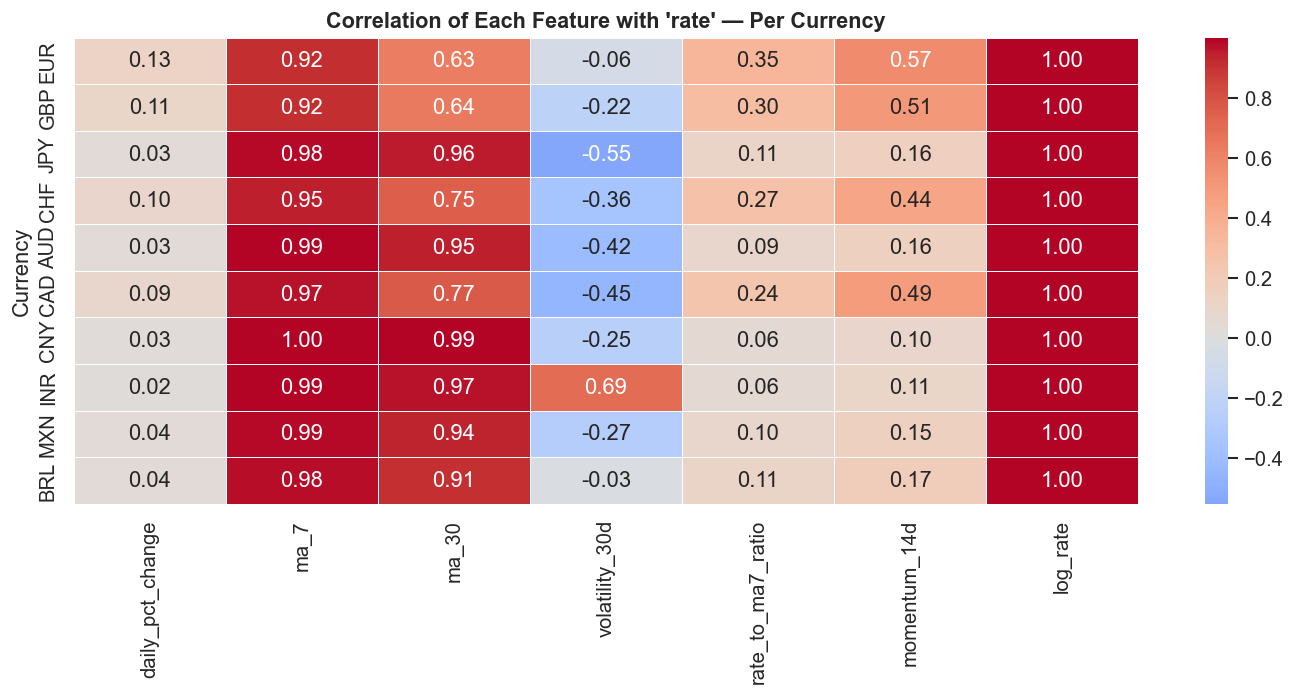

In [16]:
per_currency_corr = {}
for cur in MAJOR:
    sub = df_feat[df_feat["target_currency"] == cur][feature_cols].dropna()
    per_currency_corr[cur] = sub.corr().loc["rate"]

corr_comparison = pd.DataFrame(per_currency_corr).T
corr_comparison = corr_comparison.drop(columns=["rate"])  # self-correlation = 1

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(corr_comparison, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation of Each Feature with 'rate' — Per Currency",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Currency")
plt.tight_layout()
plt.show()

---
## 16. Pairwise Scatter — Engineered vs Raw

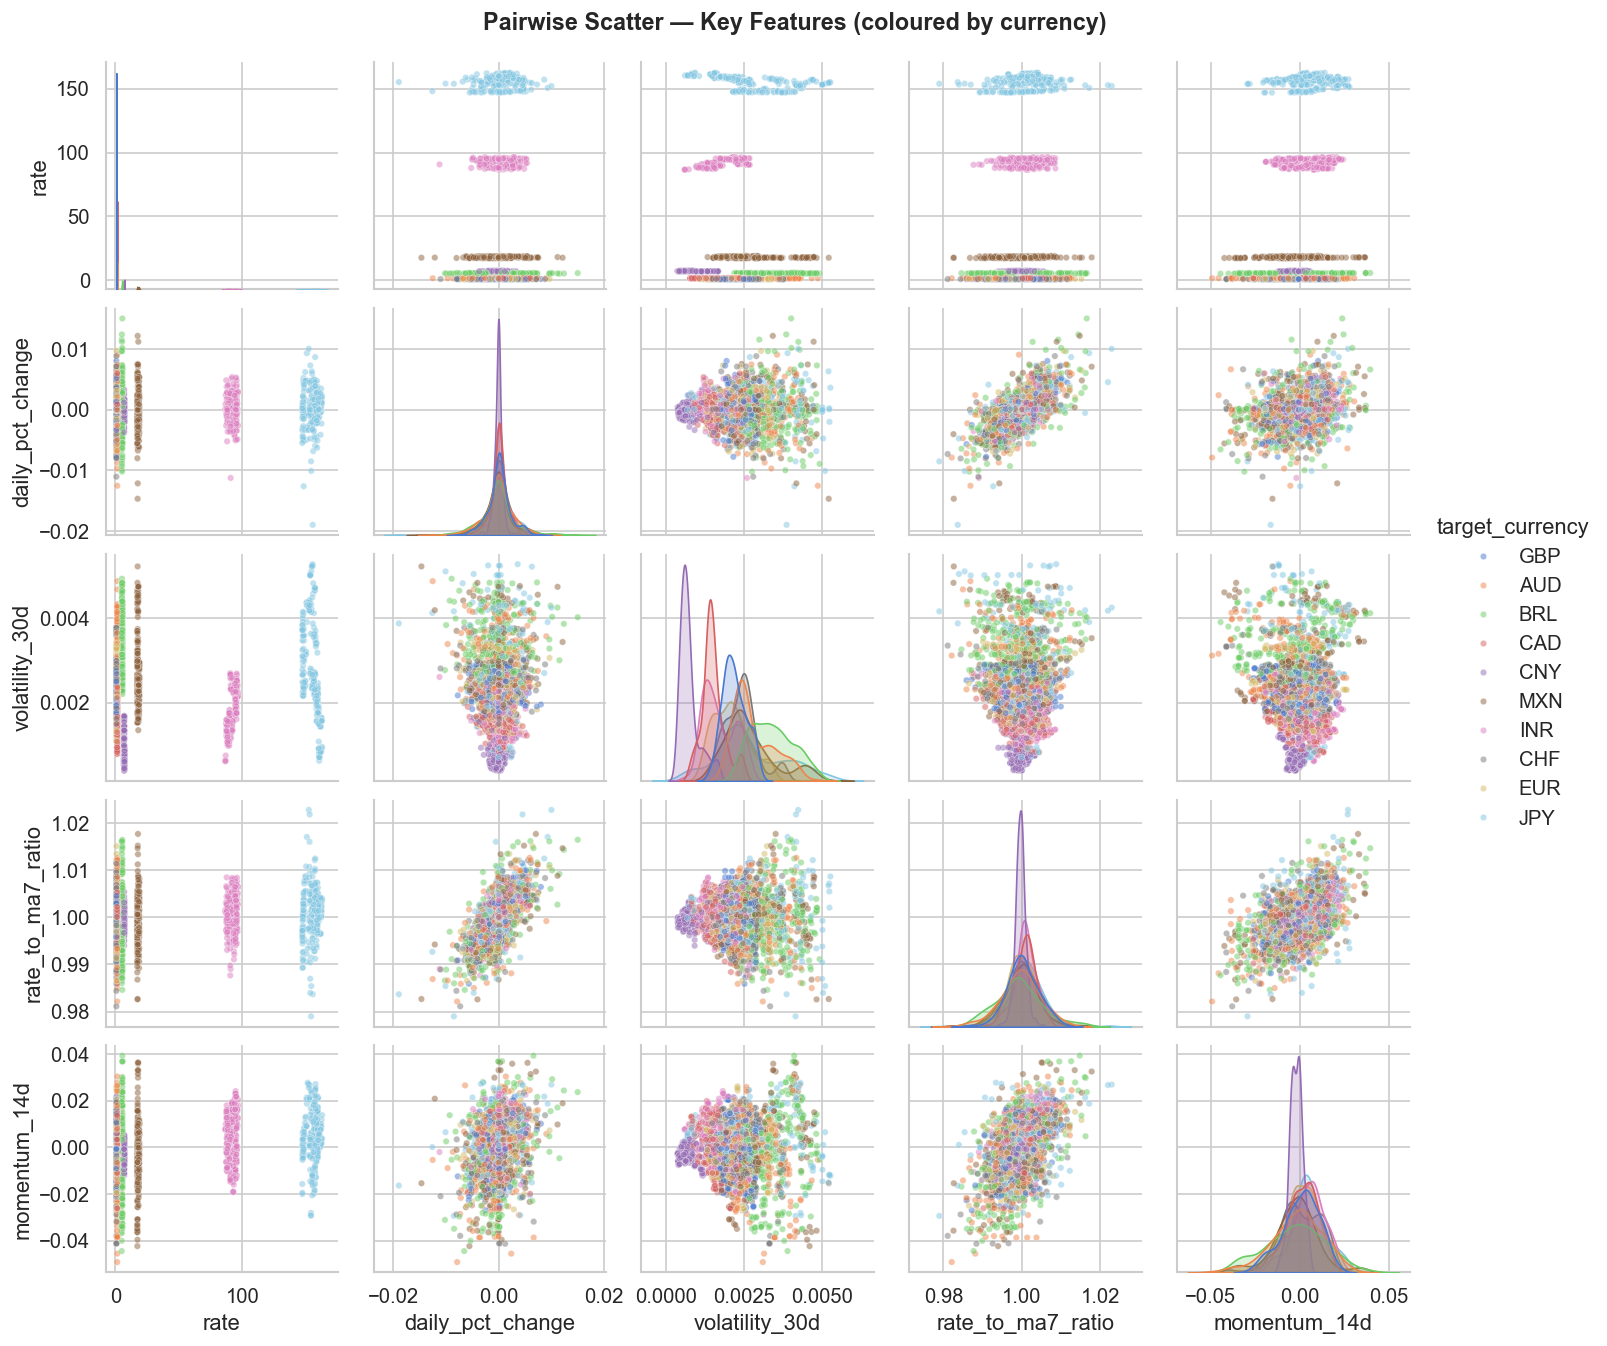

In [17]:
scatter_cols = ["rate", "daily_pct_change", "volatility_30d", "rate_to_ma7_ratio", "momentum_14d"]
sample = df_feat.dropna(subset=scatter_cols).sample(n=min(3000, len(df_feat)), random_state=42)

g = sns.pairplot(sample, vars=scatter_cols, hue="target_currency",
                 diag_kind="kde", plot_kws={"alpha": 0.5, "s": 15},
                 height=2.2, aspect=1.1)
g.fig.suptitle("Pairwise Scatter — Key Features (coloured by currency)",
               fontsize=14, fontweight="bold", y=1.02)
plt.show()

---
## 17. Volatility vs Mean Return

Classic risk-return scatter — each point is a currency.

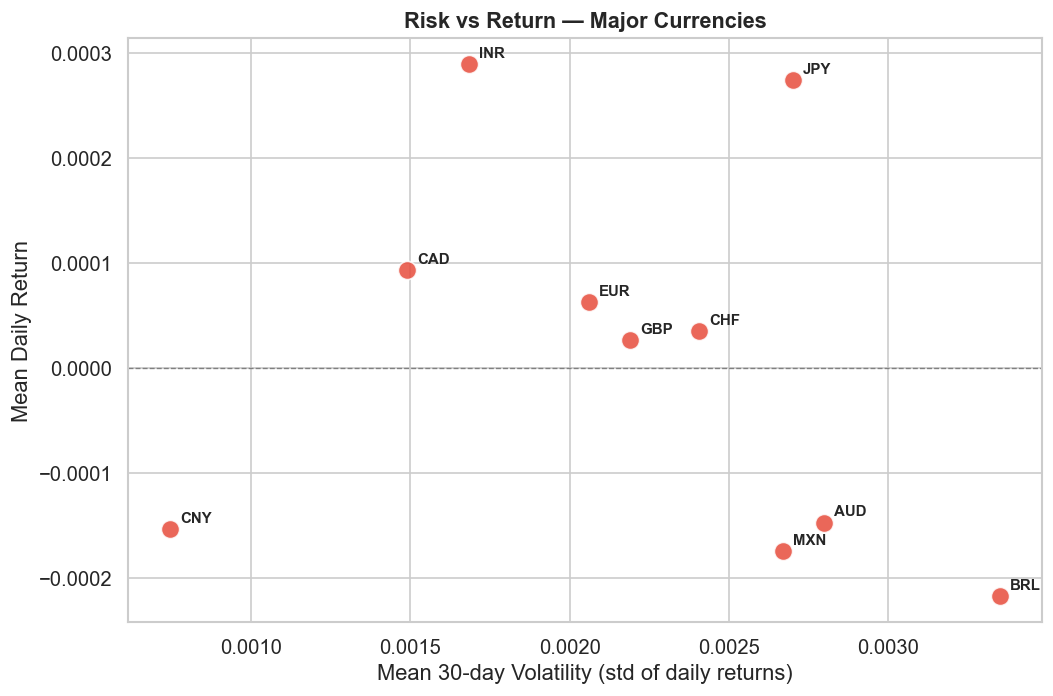

In [18]:
risk_return = (
    df_feat.dropna(subset=["daily_pct_change", "volatility_30d"])
    .groupby("target_currency")
    .agg(
        mean_return=("daily_pct_change", "mean"),
        mean_vol=("volatility_30d", "mean"),
    )
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(risk_return["mean_vol"], risk_return["mean_return"],
           s=120, c="#e74c3c", edgecolors="white", alpha=0.85, zorder=3)

for cur, row in risk_return.iterrows():
    ax.annotate(cur, (row["mean_vol"], row["mean_return"]),
                fontsize=9, fontweight="bold",
                textcoords="offset points", xytext=(6, 4))

ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.set_xlabel("Mean 30-day Volatility (std of daily returns)")
ax.set_ylabel("Mean Daily Return")
ax.set_title("Risk vs Return — Major Currencies", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 18. Summary & Key Takeaways

In [19]:
print("=" * 60)
print("  RAW DATA — EDA SUMMARY")
print("=" * 60)
print(f"")
print(f"  Total rows       : {len(df_raw):,}")
print(f"  Columns          : {list(df_raw.columns)}")
print(f"  Date range       : {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
print(f"  Unique currencies: {df_raw['target_currency'].nunique()}")
print(f"  Null values      : {df_raw.isnull().sum().sum()}")
print(f"  Exact duplicates : {exact_dupes}")
print(f"  Key duplicates   : {n_key_dupes}")
print(f"  Missing dates    : {len(missing_dates)} (mostly weekends/holidays)")
print(f"  Rate range       : {df_raw['rate'].min():.4f} → {df_raw['rate'].max():,.2f}")
print(f"  Rate skewness    : {df_raw['rate'].skew():.2f} (heavily right-skewed)")
print(f"")
print("  FEATURE ENGINEERING FINDINGS:")
print(f"  • log_rate closely tracks rate (r ≈ {corr_feat.loc['rate','log_rate']:.2f})")
print(f"  • MA features are near-perfect proxies of rate")
print(f"  • volatility_30d is independent of rate level")
print(f"  • rate_to_ma7_ratio offers a de-trended view")
print(f"  • momentum_14d weakly correlates with daily returns")
print("=" * 60)

  RAW DATA — EDA SUMMARY

  Total rows       : 51,615
  Columns          : ['date', 'base_currency', 'target_currency', 'rate']
  Date range       : 2025-07-11 → 2026-07-12
  Unique currencies: 166
  Null values      : 0
  Exact duplicates : 0
  Key duplicates   : 0
  Missing dates    : 0 (mostly weekends/holidays)
  Rate range       : 0.0002 → 1,391,109.00
  Rate skewness    : 16.64 (heavily right-skewed)

  FEATURE ENGINEERING FINDINGS:
  • log_rate closely tracks rate (r ≈ 0.87)
  • MA features are near-perfect proxies of rate
  • volatility_30d is independent of rate level
  • rate_to_ma7_ratio offers a de-trended view
  • momentum_14d weakly correlates with daily returns
